# Matrix Factorization Recommender

Predict missing ratings from small user and item factor vectors.

## What to look for

The grid is a predicted rating table; cells marked with an asterisk were missing.

This notebook uses the same small example as `main.py`. The chart preview below is embedded so it appears as soon as you open the notebook. Run the code cell to recalculate the printed results and interactive Matplotlib figure (requires NumPy and Matplotlib).


In [ ]:
"""Fill a tiny user-item table with low-rank factors."""
import numpy as np
import matplotlib.pyplot as plt
# Zero means missing; only observed ratings contribute to the training error.
ratings=np.array([[5,4,0,1],[4,0,2,1],[1,2,4,5],[0,1,5,4.]],float); observed=ratings>0
rng=np.random.default_rng(9); users=rng.normal(0,.5,(4,2)); items=rng.normal(0,.5,(4,2))
# A predicted rating is the dot product of one user's and one item's latent factor vectors.
for _ in range(3000):
    for u,i in zip(*np.where(observed)):
        error=users[u]@items[i]-ratings[u,i]
        users[u]-=.02*(2*error*items[i]+.02*users[u]); items[i]-=.02*(2*error*users[u]+.02*items[i])
# Multiply all user and item factors to estimate ratings, then keep predictions on the 1–5 scale.
prediction=np.clip(users@items.T,1,5); print("Predictions for missing ratings:")
for u,i in zip(*np.where(~observed)): print(f"user {u+1}, item {i+1}: {prediction[u,i]:.1f}")
plt.imshow(prediction,vmin=1,vmax=5,cmap="YlGnBu")
for u in range(4):
    for i in range(4): plt.text(i,u,f"{prediction[u,i]:.1f}"+("*" if not observed[u,i] else ""),ha="center",va="center")
plt.xticks(range(4),["item 1","item 2","item 3","item 4"]); plt.yticks(range(4),["user 1","user 2","user 3","user 4"])
plt.title("Rating estimates (* was missing)"); plt.colorbar(label="predicted rating")
plt.tight_layout(); plt.show()


## Visualization preview

The saved preview below illustrates the project's main idea. Re-run the code cell above to generate the chart from the example data.


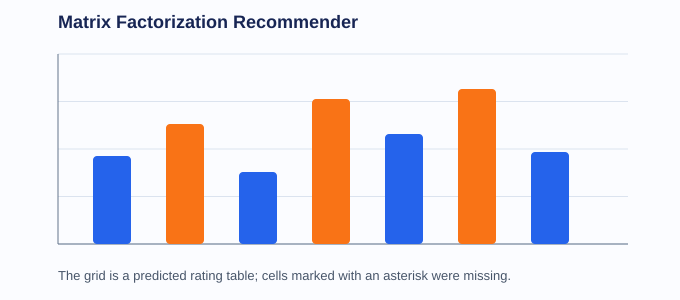

In [ ]:
# This cell displays the chart preview saved in the notebook.
